In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
tips = sns.load_dataset("tips")

bill = tips["total_bill"].values
tip = tips["tip"].values

In [6]:
def local_weight(x0, X, tau):
    weights = np.exp(-np.sum((X - x0) ** 2, axis=1) / (2 * tau ** 2))
    return weights

In [7]:
def local_regression(X, y, tau):
    y_pred = np.zeros(len(X))

    for i in range(len(X)):
        weights = local_weight(X[i], X, tau)
        W = np.diag(weights)

        theta = np.linalg.pinv(X.T @ W @ X) @ (X.T @ W @ y)

        y_pred[i] = X[i] @ theta

    return y_pred

In [8]:
X = np.column_stack((np.ones(len(bill)), bill))

y = tip
tau = 0.5

y_pred = local_regression(X, y, tau)

In [9]:
sort_idx = np.argsort(bill)

xsort = bill[sort_idx]
ysort = y_pred[sort_idx]

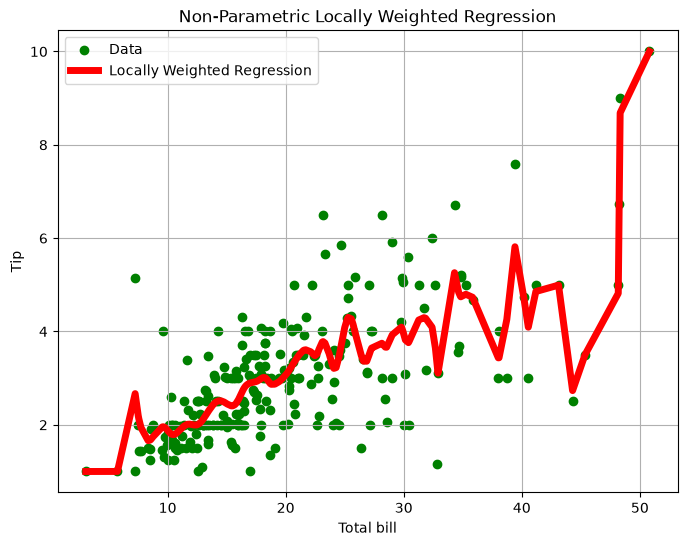

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    bill,
    tip,
    color="green",
    label="Data"
)

plt.plot(
    xsort,
    ysort,
    color="red",
    linewidth=5,
    label="Locally Weighted Regression"
)

plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.title("Non-Parametric Locally Weighted Regression")

plt.legend()
plt.grid(True)

plt.show()